In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
%matplotlib inline

## READ NAMES DATA

In [2]:
names = open('names.txt', 'r').read().splitlines()
names[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

## CREATE VOCABULARY

In [3]:
vocabulary = sorted(list(set(''.join(names))))
stoi = {s:i+1 for i, s in enumerate(vocabulary)}
stoi['.']=0

itos = {i:s for s,i in stoi.items()}

In [4]:
vocab_size = len(itos)
vocab_size

27

## GENERATE DATASET

In [5]:
block_size = 3
def build_dataset(names):

  x = []
  y = []

  for name in names:
    context = [0]*block_size
    for ch in name + '.':
      x.append(context)
      ix = stoi[ch]
      y.append(ix)
      context = context[1:] + [ix]

  xs = torch.tensor(x)
  ys = torch.tensor(y)
  return xs, ys

In [6]:
import random
random.seed(42)
random.shuffle(names)

n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

xTr, yTr = build_dataset(names[:n1])
xVal, yVal = build_dataset(names[n1:n2])
xTe, yTe = build_dataset(names[n2:])

print(xTr.shape, yTr.shape)
print(xVal.shape, yVal.shape)
print(xTe.shape, yTe.shape)

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


# E01 : Testing with 0 gain across the network


In [7]:
class Lin:

  def __init__(self, fan_in, fan_out, generator, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=generator)/fan_in**0.5   # remember it is fan_in coz variance dependent on dimensionality of the input this weight receives
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias]) # [self.weight] converts tensor weights to list

In [8]:
class BatchNorm1d:

  def __init__(self, dim, eps= 1e-05, momentum=0.1):

    self.eps = eps
    self.momentum = momentum
    self.training = True

    # learnable parameters
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    # stats
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):

    if self.training:
      bmean = x.mean(0, keepdim=True) # batch_mean
      bvar = x.var(0, keepdim=True)   # batch_var
    else:
      bmean = self.running_mean
      bvar = self.running_var

    xhat = (x - bmean)/ torch.sqrt(bvar+self.eps)
    self.out = self.gamma * xhat + self.beta

    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum)*self.running_mean + self.momentum * bmean
        self.running_var = (1 - self.momentum)*self.running_var + self.momentum * bvar

    return self.out

  def parameters(self):
    return [self.gamma, self.beta]


In [9]:
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

In [11]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

layers = [
    Lin(block_size * embed_size, hidden_size, g, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Lin(hidden_size, hidden_size, g, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Lin(hidden_size, vocab_size, g, bias=False), BatchNorm1d(vocab_size)
]


# Set all parameters to zero
with torch.no_grad():
    for layer in layers:
        if isinstance(layer, Lin):
            layer.weight *= 0.0  # Zero out weights in linear layers
        elif isinstance(layer, BatchNorm1d):
            layer.gamma *= 0.0   # Zero out BatchNorm scaling parameters

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


16424


In [12]:
[p.nelement() for p in parameters]

[270, 3000, 100, 100, 10000, 100, 100, 2700, 27, 27]

In [14]:
# Stat Trackers

log_loss = []

lindata = []
bnormdatagamma = []
bnormdatabeta = []
for layer in layers:
    if isinstance(layer, Lin):
      lindata.append([])
    elif isinstance(layer, BatchNorm1d):
      bnormdatagamma.append([])
      bnormdatabeta.append([])
ud = []


In [15]:
num_epochs = 50000
batch_size = 32

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]

  x = embed.view(xTr[ind].shape[0], -1)

  # linear layer
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yTr[ind])

  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph

  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

  linlayer = 0
  b1layer = 0
  with torch.no_grad():
    for layer in layers:
        if isinstance(layer, Lin):
            lindata[linlayer].append(layer.parameters()[0].mean())
            linlayer += 1
        elif isinstance(layer, BatchNorm1d):
            bnormdatagamma[b1layer].append(layer.parameters()[0].mean())
            bnormdatabeta[b1layer].append(layer.parameters()[1].mean())
            b1layer += 1

  with torch.no_grad():
    ud.append([((lr*p.grad).std()/p.data.std()).log10().item() for p in parameters])

  if i>1000:
    break

      0/  50000:3.2958


layer 2 (Tanh): mean 0.00, std 0.00, saturation 0.00%
layer 5 (Tanh): mean 0.00, std 0.00, saturation 0.00%


Text(0.5, 1.0, 'Tanh Activation Distribution')

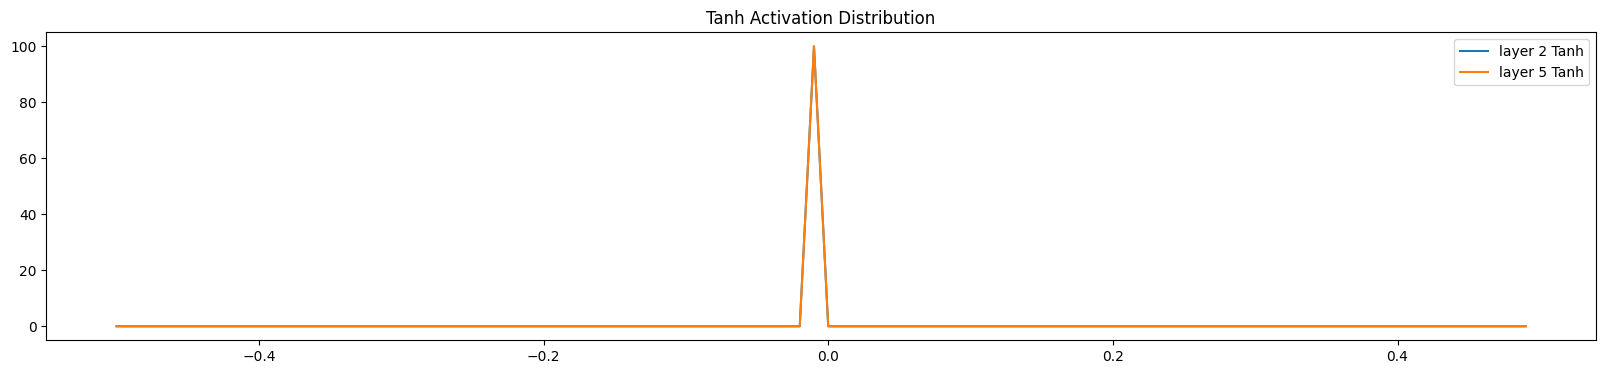

In [18]:
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out
    print(f'layer {i} ({layer.__class__.__name__}): mean {t.mean():.2f}, std {t.std():.2f}, saturation {(t.abs()>0.97).float().mean()*100:.2f}%')
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('Tanh Activation Distribution')

layer 2 (Tanh): mean +0.000000, std 0.000000e+00
layer 5 (Tanh): mean +0.000000, std 0.000000e+00


Text(0.5, 1.0, 'Tanh Gradient Distribution')

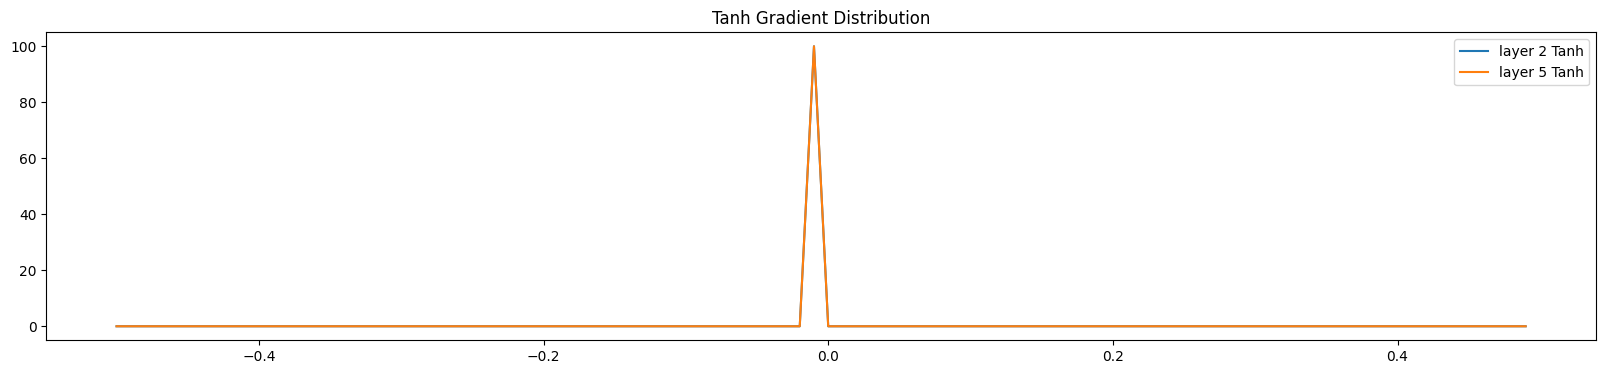

In [19]:
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('Tanh Gradient Distribution')

layer 0 (Lin): mean 0.00, std 0.00, saturation 0.00%
layer 3 (Lin): mean 0.00, std 0.00, saturation 0.00%
layer 6 (Lin): mean 0.00, std 0.00, saturation 0.00%


Text(0.5, 1.0, 'Linear Layer Activation Distribution')

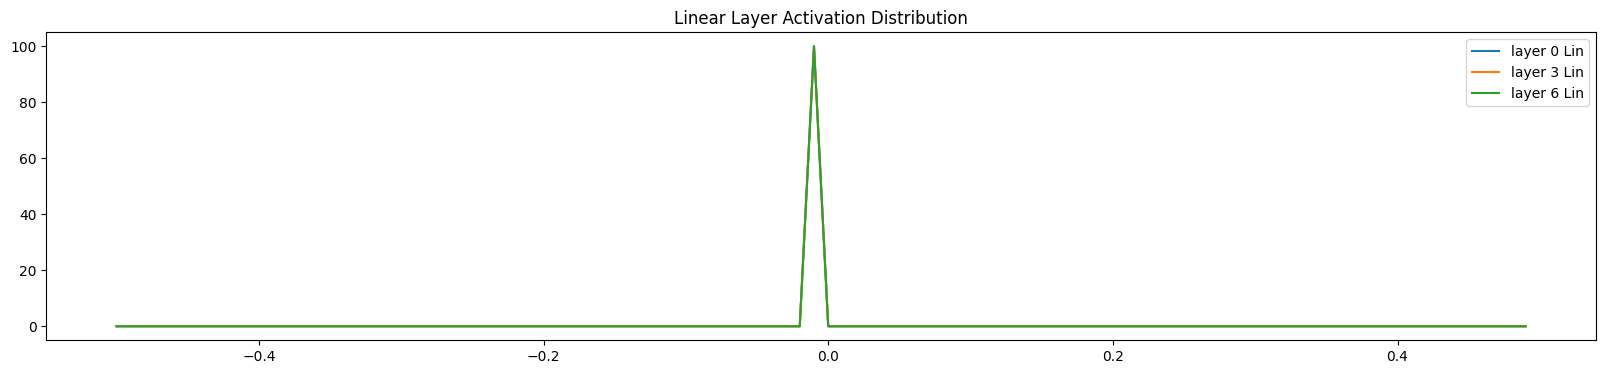

In [20]:
# we're back to the extreme gradients
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Lin):
    t = layer.out
    print(f'layer {i} ({layer.__class__.__name__}): mean {t.mean():.2f}, std {t.std():.2f}, saturation {(t.abs()>0.97).float().mean()*100:.2f}%') # recall, saturation is the percentage of white grids
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('Linear Layer Activation Distribution')

layer 0 (Lin): mean +0.000000, std 0.000000e+00
layer 3 (Lin): mean +0.000000, std 0.000000e+00
layer 6 (Lin): mean +0.000000, std 0.000000e+00


Text(0.5, 1.0, 'Linear Layer Gradient Distribution')

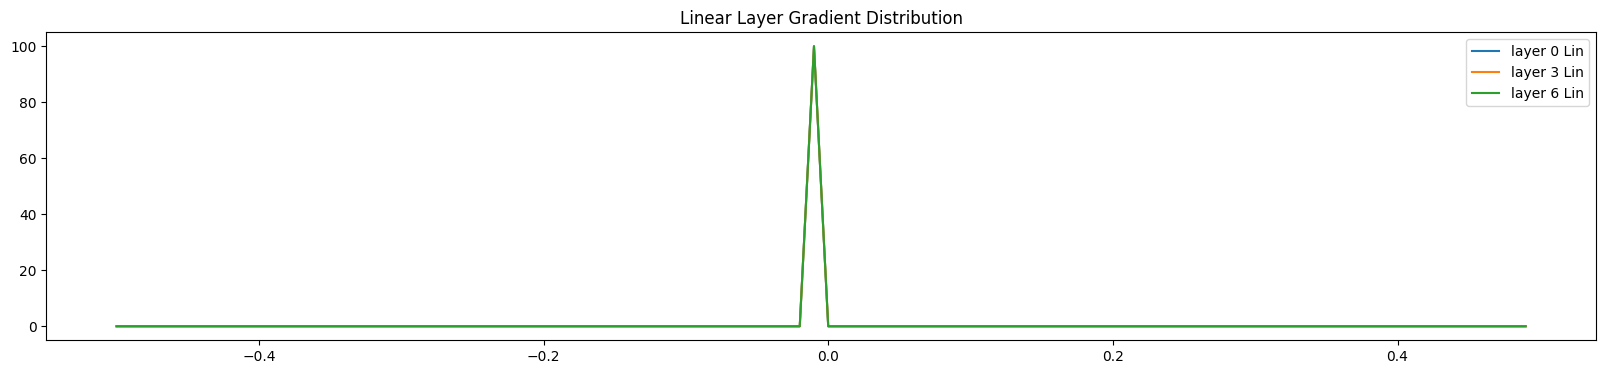

In [21]:
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Lin):
    t = layer.out.grad
    print('layer %d (%s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('Linear Layer Gradient Distribution')

Text(0.5, 1.0, 'Linear Layer Parameter Updates')

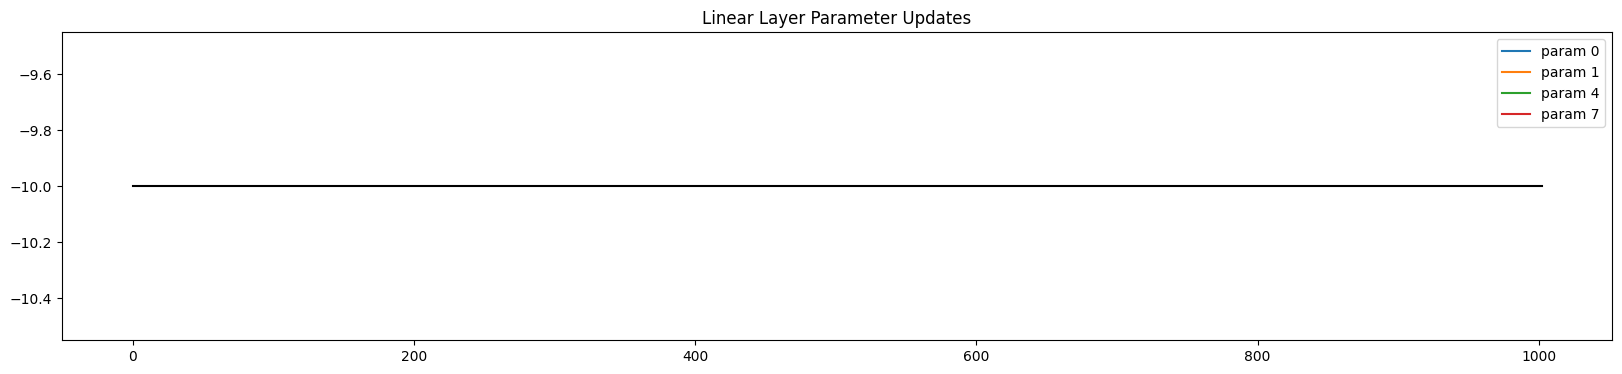

In [22]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2: # plotting only the parameters that are 2 dimensional matrices, i.e weight parameters
    plt.plot([ud[j][i] for j in range(len(ud))]) # j indexes the epoch/step, i indexes the specific parameter appended to ud list
    legends.append(f'param {i}')
plt.plot([0, len(ud)], [-10, -10], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);
plt.title('Linear Layer Parameter Updates')

In [36]:
[p.nelement() for p in parameters]

[270, 3000, 100, 100, 10000, 100, 100, 2700, 27, 27]

In [51]:
for i, layer in enumerate(layers):
  for i,p in enumerate(layer.parameters()):
    if p.ndim == 1:
      print(p, layer.__class__.__name__)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.], requires_grad=True) BatchNorm1d
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.], requires_grad=True) BatchNorm1d
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

Text(0.5, 1.0, 'Batch Norm Parameter Updates')

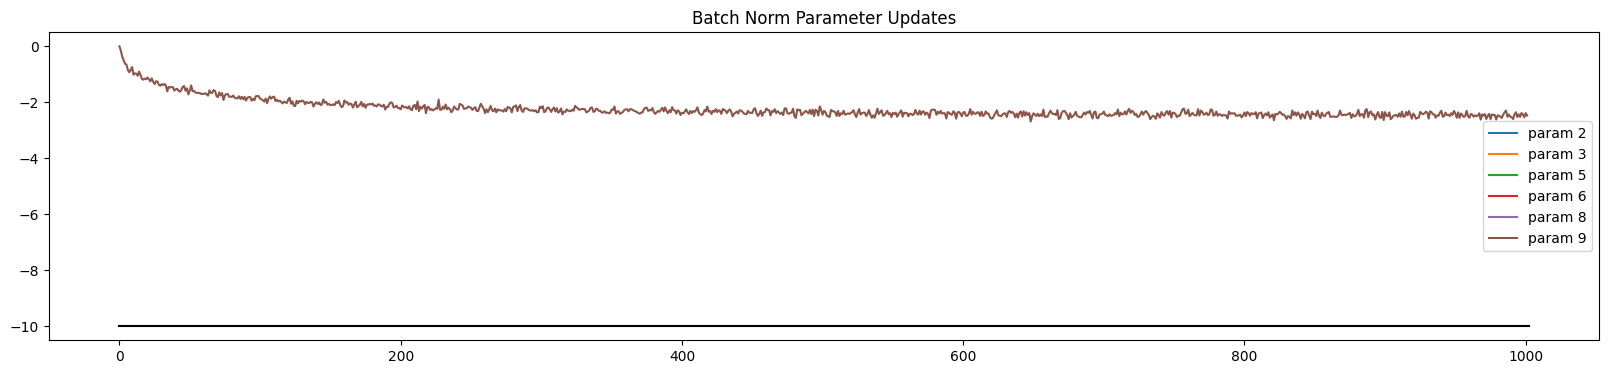

In [48]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
# for i, layer in enumerate(layers):
#   print(len(layer.parameters()), layer.__class__.__name__)
for i,p in enumerate(parameters):
  if p.ndim == 1: # plotting only the parameters that are 2 dimensional matrices, i.e weight parameters
    plt.plot([ud[j][i] for j in range(len(ud))]) # j indexes the epoch/step, i indexes the specific parameter appended to ud list
    legends.append(f'param {i}')
plt.plot([0, len(ud)], [-10, -10], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);
plt.title('Batch Norm Parameter Updates')

Text(0.5, 1.0, 'Parameter Data Trend')

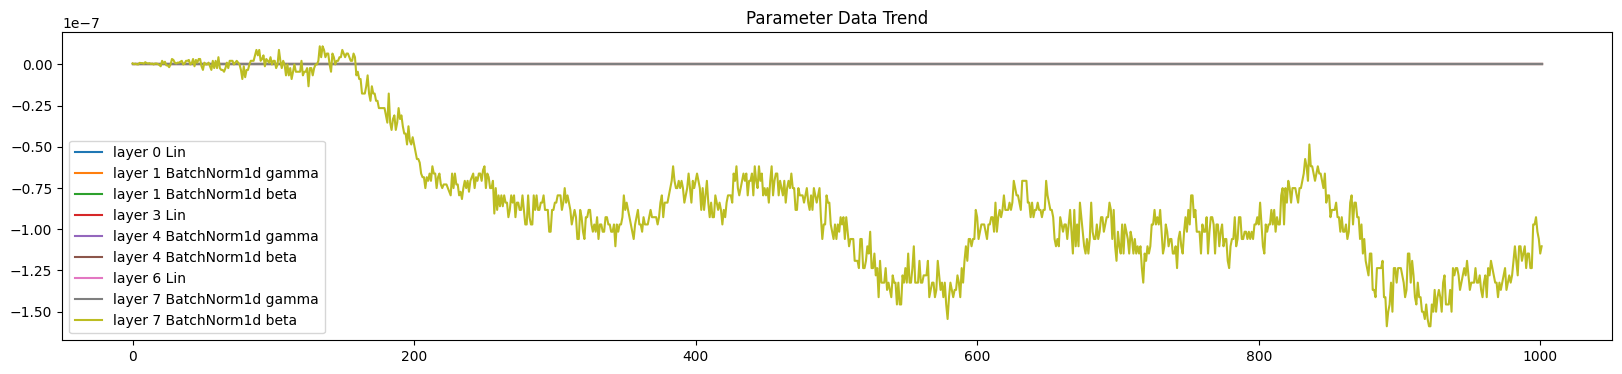

In [52]:
plt.figure(figsize=(20, 4))

legends = []

linlayer = 0
b1layer = 0

for i, layer in enumerate(layers):
  if isinstance(layer, Lin):
    plt.plot(lindata[linlayer])
    linlayer += 1
    legends.append(f'layer {i} {layer.__class__.__name__}')
  elif isinstance(layer, BatchNorm1d):
    plt.plot(bnormdatagamma[b1layer])
    legends.append(f'layer {i} {layer.__class__.__name__} gamma')
    plt.plot(bnormdatabeta[b1layer])
    legends.append(f'layer {i} {layer.__class__.__name__} beta')
    b1layer += 1

plt.legend(legends)
plt.title('Parameter Data Trend')

# Result

So basically if all starts out at 0, the model doesn't converge(at least in the 600000 iterations that I ran it for).

All the gradients are 0, no learning across the layers. Only learning that happens is in the final bias layer - which gets direct update from loss (since the tanh after last batchnorm layer is just a pass-through for loss gradients).

# E02 : Fold the gamma and beta from BatchNorm layer into preceding Linear layer in eval mode

$$ \gamma * \frac{[\textbf{output of linear layer} - \mu]}{\sqrt{\textbf{var} + ϵ}} + \beta $$

$$ \gamma * \frac{w ^{T} x + b - \mu}{\sqrt{\textbf{var} + ϵ}} + β $$

$$ \frac{\gamma}{\sqrt{\textbf{var} + ϵ}}  * w ^{T} x + \frac{\gamma}{\sqrt{\textbf{var} + ϵ}} * (b-\mu)  + β $$

$$ \textbf{New Weight} = \frac{\gamma}{\sqrt{\textbf{var} + ϵ}} * w  $$

$$ \textbf{New Bias} = \frac{\gamma}{\sqrt{\textbf{var} + ϵ}} * (b-\mu)  + β $$

In [7]:
class Lin:
  def __init__(self, fan_in, fan_out, generator, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=generator)/fan_in**0.5   # remember it is fan_in coz variance dependent on dimensionality of the input this weight receives
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias]) # [self.weight] converts tensor weights to list

In [8]:
# MODIFIED FOR PASS THROUGH IN EVAL MODE

class BatchNorm1d:

  def __init__(self, dim, eps= 1e-05, momentum=0.1):

    self.eps = eps
    self.momentum = momentum
    self.training = True

    # learnable parameters
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    # stats
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):

    if not self.training:
      return x

    # shape of x [num_inputs * hidden size] --> mean over dim = 0 gives us [1* hidden size]
    bmean = x.mean(0, keepdim=True) # batch_mean
    bvar = x.var(0, keepdim=True)   # batch_var

    xhat = (x - bmean)/ torch.sqrt(bvar+self.eps)
    self.out = self.gamma * xhat + self.beta

    with torch.no_grad():
      self.running_mean = (1 - self.momentum)*self.running_mean + self.momentum * bmean
      self.running_var = (1 - self.momentum)*self.running_var + self.momentum * bvar

    return self.out

  def parameters(self):
    return [self.gamma, self.beta]


In [9]:
# Checking self.gamma * xhat + self.beta broadcasting
out = torch.randn(10) * torch.randn((5, 10))
out.shape

torch.Size([5, 10])

In [10]:
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

In [13]:
# Defining Network
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

layers = [
    Lin(block_size * embed_size, hidden_size, g, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Lin(hidden_size, hidden_size, g, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Lin(hidden_size, vocab_size, g, bias=False), BatchNorm1d(vocab_size)
]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Lin):
      layer.weight *= 1.0

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


16424


In [14]:
# TRAINING

max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, xTr.shape[0], (batch_size,), generator=g)
  Xb, Yb = xTr[ix], yTr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item ():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.3138


In [15]:
for i, layer in enumerate(layers):
  if isinstance(layer, Lin):
    print(layer.weight.shape)

torch.Size([30, 100])
torch.Size([100, 100])
torch.Size([100, 27])


In [16]:
for i, layer in enumerate(layers):
  if isinstance(layer, BatchNorm1d):
    print(layer.running_mean.shape, layer.gamma.shape)

torch.Size([1, 100]) torch.Size([100])
torch.Size([1, 100]) torch.Size([100])
torch.Size([1, 27]) torch.Size([27])


# Folding γ and β into weights of preceding Linear layer

In [17]:
# put layers into eval mode
for layer in layers:
  if isinstance(layer, BatchNorm1d):
    layer.training = False

In [20]:
# FOLD GAMMA AND BETA INTO WEIGHTS
with torch.no_grad():
    for i, layer in enumerate(layers):
        if isinstance(layer, Lin):
            nextbatchnormlayer = i+1

            gamma = layers[nextbatchnormlayer].gamma # (shape: [hidden_size] or [output size of previous linear layer])
            beta = layers[nextbatchnormlayer].beta # (shape: [hidden_size] or [output size of previous linear layer])
            multiplying_factor = gamma / torch.sqrt(layers[nextbatchnormlayer].running_var+layers[nextbatchnormlayer].eps)

            layer.weight *= multiplying_factor
            if layer.bias:
                layer.bias = multiplying_factor * (layer.bias - layers[nextbatchnormlayer].running_mean) + beta
            else:
                layer.bias = - multiplying_factor * layers[nextbatchnormlayer].running_mean + beta

In [21]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (xTr, yTr),
    'val': (xVal, yVal),
    'test': (xTe, yTe),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)

  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.435354471206665
val 2.429990530014038


# Verifying output is the same with/without folding

## Original Model

In [7]:
class Lin:
  def __init__(self, fan_in, fan_out, generator, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=generator)/fan_in**0.5   # remember it is fan_in coz variance dependent on dimensionality of the input this weight receives
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias]) # [self.weight] converts tensor weights to list


class BatchNorm1d:

  def __init__(self, dim, eps= 1e-05, momentum=0.1):

    self.eps = eps
    self.momentum = momentum
    self.training = True

    # learnable parameters
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    # stats
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):

    if self.training:
      bmean = x.mean(0, keepdim=True) # batch_mean
      bvar = x.var(0, keepdim=True)   # batch_var
    else:
      bmean = self.running_mean
      bvar = self.running_var

    xhat = (x - bmean)/ torch.sqrt(bvar+self.eps)
    self.out = self.gamma * xhat + self.beta

    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum)*self.running_mean + self.momentum * bmean
        self.running_var = (1 - self.momentum)*self.running_var + self.momentum * bvar

    return self.out

  def parameters(self):
    return [self.gamma, self.beta]


class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


In [8]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

layers = [
    Lin(block_size * embed_size, hidden_size, g, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Lin(hidden_size, hidden_size, g, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Lin(hidden_size, vocab_size, g, bias=False), BatchNorm1d(vocab_size)
]


with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Lin):
      layer.weight *= 1.0

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


16424


In [9]:
# TRAINING

max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, xTr.shape[0], (batch_size,), generator=g)
  Xb, Yb = xTr[ix], yTr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item ():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 10000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.3138
  10000/ 200000: 2.7694


In [10]:
# put layers into eval mode
for layer in layers:
  if isinstance(layer, BatchNorm1d):
    layer.training = False

In [11]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (xTr, yTr),
    'val': (xVal, yVal),
    'test': (xTe, yTe),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)

  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

start_train_time = time.time()
split_loss('train')
end_train_time = time.time()
split_loss('val')
end_val_time = time.time()


print(f"Inference time on train dataset {end_train_time - start_train_time}")
print(f"Inference time on validation dataset {end_val_time - end_train_time}")

output_without_folding = x

train 2.222215414047241
val 2.2323436737060547
Inference time on train dataset 0.7351970672607422
Inference time on validation dataset 0.08264303207397461


## With Folding

In [12]:
class Identity:
  def __call__(self, x):
    return x

  def parameters(self):
    return []


In [13]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

layers = [
    Lin(block_size * embed_size, hidden_size, g, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Lin(hidden_size, hidden_size, g, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Lin(hidden_size, vocab_size, g, bias=False), BatchNorm1d(vocab_size)
]


with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Lin):
      layer.weight *= 1.0

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


16424


In [14]:
# TRAINING

max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, xTr.shape[0], (batch_size,), generator=g)
  Xb, Yb = xTr[ix], yTr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item ():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 10000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.3138
  10000/ 200000: 2.7694


In [17]:
def fuse_linear_bn_eval(layers):
  # FOLD GAMMA AND BETA INTO WEIGHTS
  with torch.no_grad():
      for i, layer in enumerate(layers):
          if isinstance(layer, Lin):
              nextbatchnormlayer = i+1

              gamma = layers[nextbatchnormlayer].gamma # (shape: [hidden_size] or [output size of previous linear layer])
              beta = layers[nextbatchnormlayer].beta # (shape: [hidden_size] or [output size of previous linear layer])
              multiplying_factor = gamma / torch.sqrt(layers[nextbatchnormlayer].running_var+layers[nextbatchnormlayer].eps)

              layer.weight *= multiplying_factor
              if layer.bias:
                  layer.bias = multiplying_factor * (layer.bias - layers[nextbatchnormlayer].running_mean) + beta
              else:
                  layer.bias = - multiplying_factor * layers[nextbatchnormlayer].running_mean + beta

  # ELIMINATE BATCHNORM LAYERS
  layers = [layer if not isinstance(layer, BatchNorm1d) else Identity() for layer in layers]

  return layers

# Fuse the layers
layers = fuse_linear_bn_eval(layers)

# Check if BatchNorm layers dropped and replaced with Identity
for layer in layers:
  print(layer.__class__.__name__)



Lin
Identity
Tanh
Lin
Identity
Tanh
Lin
Identity


In [18]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (xTr, yTr),
    'val': (xVal, yVal),
    'test': (xTe, yTe),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)

  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

start_train_time = time.time()
split_loss('train')
end_train_time = time.time()
split_loss('val')
end_val_time = time.time()


print(f"Inference time on train dataset with folding {end_train_time - start_train_time}")
print(f"Inference time on validation dataset with folding {end_val_time - end_train_time}")

output_with_folding = x

train 2.222215414047241
val 2.2323436737060547
Inference time on train dataset with folding 0.41471362113952637
Inference time on validation dataset with folding 0.04543876647949219


In [19]:
with torch.no_grad():
    assert torch.allclose(output_with_folding, output_without_folding, atol=1e-5)

## RESULTS

Inference time (for the small dataset used here) reduced by 50% without compromising on the accuracy of the inference output.